# Sequential Graph 

### Objectives

1. Create multiple `Nodes` that sequentially process and update different parts of the state.
2. Connect `Nodes` together in a graph.
3. Invoke the `Graph` and see how the state is transformed step-by-step.


**Main Goal**: create and handle multiple `Nodes`.

In [79]:
from typing import TypedDict
from langgraph.graph import StateGraph

In [80]:
class AgentState(TypedDict):
    name : str
    age: str
    final: str

In [81]:
def first_node(state: AgentState) -> AgentState:
    """
    First node of our sequence.
    """
    state["final"] = f"Hi, {state["name"]}, "
    return state

def second_node(state : AgentState) -> AgentState:
    """
    Second node of our sequence
    """
    state["final"] = state["final"] + f" You are {state["age"]} years old"
    return state

In [82]:
graph = StateGraph(AgentState)

graph.add_node("first_node", first_node)
graph.add_node("second_node", second_node)


graph.set_entry_point("first_node")

graph.add_edge("first_node", "second_node")

graph.set_finish_point("second_node")

app = graph.compile()

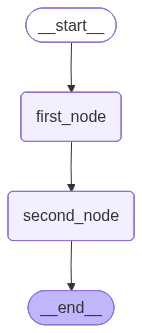

In [83]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [84]:
result = app.invoke({"name": "Charlie", "age": 20})

print(result)

{'name': 'Charlie', 'age': 20, 'final': 'Hi, Charlie,  You are 20 years old'}


---

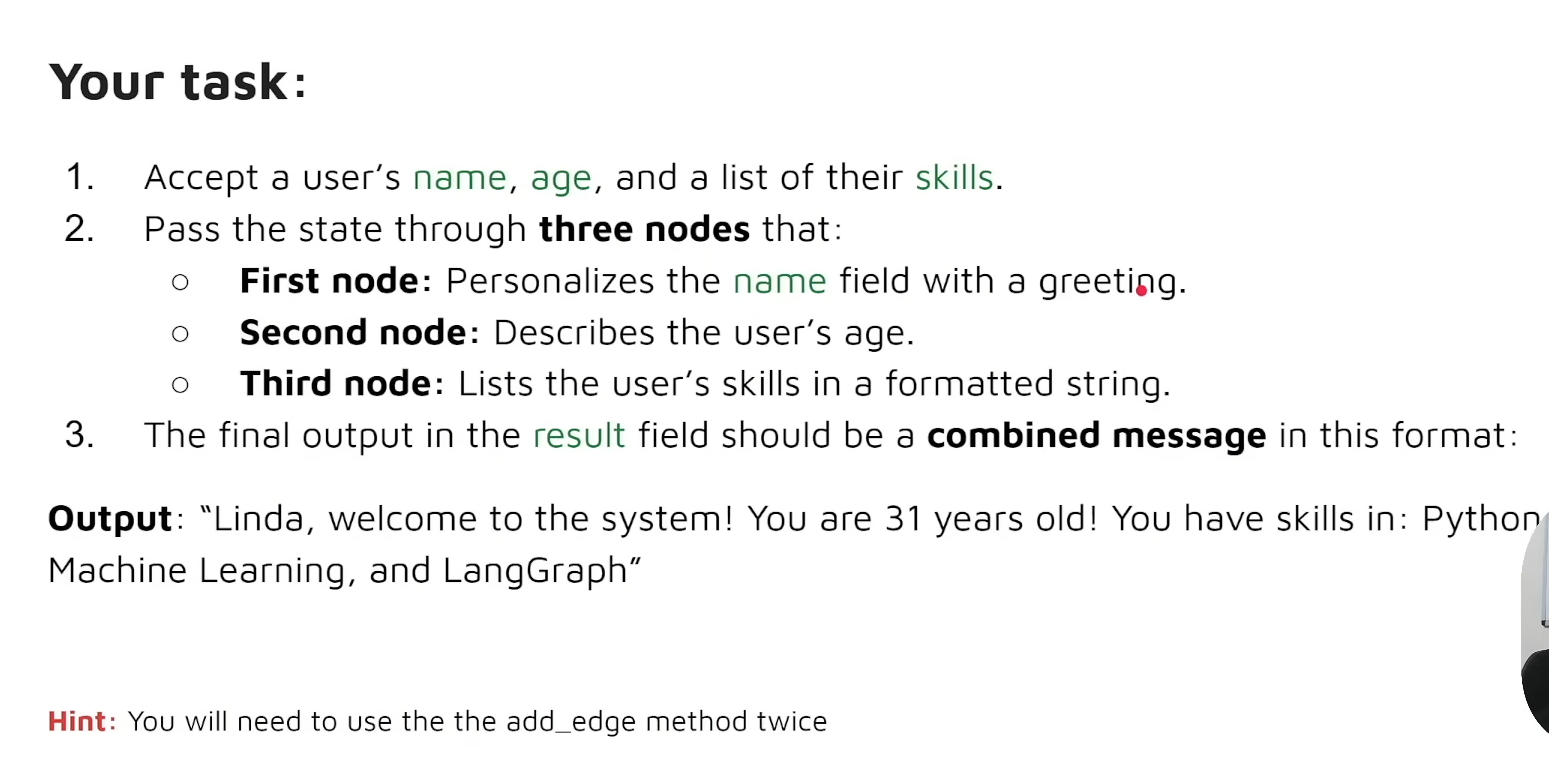

In [85]:
from typing import List

class AgentState2(TypedDict):
    name : str
    age: str
    skills : List[str]
    final: str

In [86]:
def first_node(state: AgentState2) -> AgentState2:
    """
    First node of our sequence.
    """
    state["final"] = f"{state["name"]}, welcome to the system! "
    return state

def second_node(state : AgentState2) -> AgentState2:
    """
    Second node of our sequence
    """
    state["final"] = state["final"] + f" You are {state["age"]} years old"
    return state

def third_node(state: AgentState2) -> AgentState2:
    """
    Third node of the sequence describing the user's skills
    """
    skills_str = ", ".join(state["skills"][:-1]) + f" and {state['skills'][-1]}"
    state["final"] = state["final"] + f"You have skills in: {skills_str}"
    return state

In [87]:
graph_2 = StateGraph(AgentState2)

graph_2.add_node("first_node", first_node)
graph_2.add_node("second_node", second_node)
graph_2.add_node("third_node", third_node)

graph_2.set_entry_point("first_node")

graph_2.add_edge("first_node", "second_node")
graph_2.add_edge("second_node", "third_node")

graph_2.set_finish_point("third_node")

app_2 = graph_2.compile()

In [88]:
result_2 = app_2.invoke({"name": "Charlie", "age": 20, "skills": ["Python", "ML"]})

print(result_2)

{'name': 'Charlie', 'age': 20, 'skills': ['Python', 'ML'], 'final': 'Charlie, welcome to the system!  You are 20 years oldYou have skills in: Python and ML'}
